# Fuzzy C-Means - H&M (simple)


Evaluación del número de clusters y ajuste final del modelo. El `k` recomendado se selecciona mediante el mayor coeficiente silhouette.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from modeling_functions import (
    fuzzy_cmeans_metrics,
    plot_clustering_metrics,
    analyze_clusters,
    fit_clustering_model,
    save_clustering_metrics,
)
import pandas as pd

## Carga y preparación de los datos


In [2]:
df_scaled = pd.read_csv("../../../scaled_data/hym_scaled.csv")
df_original = pd.read_csv("../../../simple_datasets/hym_model_simple.csv")

# Conserva en el escalado solo las variables incluidas en esta versión del dataset.
columnas_modelo = [col for col in df_original.columns if col in df_scaled.columns]
df_scaled_modelo = df_scaled[columnas_modelo].copy()
X = df_scaled_modelo.drop(columns=["customer_id"], errors="ignore")

print(f"Observaciones: {X.shape[0]:,}")
print(f"Variables de clustering: {X.shape[1]}")
display(X.head())

Observaciones: 1,362,281
Variables de clustering: 3


,recency,frequency,monetary
0,-1.216313,0.926194,0.765377
1,-0.614156,1.811026,1.771317
2,-1.404203,0.565013,0.847795
3,1.106440,-1.007279,-1.056769
4,-0.918963,0.413566,0.433500


## Evaluación del número de clusters


In [3]:
resultados_fuzzy = fuzzy_cmeans_metrics(X)
display(resultados_fuzzy)

,k,silhouette,calinski_harabasz,davies_bouldin,fpc,objective_function,iterations,tiempo_segundos
0,2,0.497600,1.962447e+06,0.761190,0.786584,1.309230e+06,23,5.872886
1,3,0.409354,1.779178e+06,0.911988,0.666687,7.480563e+05,50,16.104120
2,4,0.378630,1.709061e+06,0.933977,0.598398,5.139681e+05,47,19.385403
3,5,0.373245,1.600474e+06,0.974587,0.541758,3.966619e+05,126,60.301507
4,6,0.341989,1.506553e+06,0.992250,0.499300,3.205521e+05,300,162.711564
5,7,0.310648,1.453762e+06,1.006453,0.465686,2.676131e+05,198,120.375819
6,8,0.292417,1.348484e+06,1.102023,0.435890,2.302692e+05,300,204.542415
7,9,0.295273,1.335076e+06,1.062879,0.417199,2.012944e+05,152,116.045704
8,10,0.285291,1.264960e+06,1.123689,0.394806,1.793127e+05,229,190.887736


In [4]:
tabla_metricas = save_clustering_metrics(
    resultados_fuzzy,
    model_name="fuzzy",
    dataset_name="hym",
    dataset_version="simple",
)

print("Métricas consolidadas en ../../../results/clustering_metrics.csv")
display(tabla_metricas)

Métricas consolidadas en ../../../results/clustering_metrics.csv


,model,dataset,dataset_version,k,silhouette,calinski_harabasz,davies_bouldin,inertia,tiempo_segundos,n_clusters_found,fpc,objective_function,iterations,bic,aic
0,birch,hym,extended,2,0.340654,930935.773165,1.105585,NaN,56.925452,2.0,NaN,NaN,NaN,NaN,NaN
1,birch,hym,extended,3,0.230760,688890.908136,1.436553,NaN,55.993544,3.0,NaN,NaN,NaN,NaN,NaN
2,birch,hym,extended,4,0.203823,524871.689920,1.792945,NaN,55.849959,4.0,NaN,NaN,NaN,NaN,NaN
3,birch,hym,extended,5,0.191449,438249.783633,1.834154,NaN,56.909790,5.0,NaN,NaN,NaN,NaN,NaN
4,birch,hym,extended,6,0.148712,376866.681427,2.094143,NaN,56.928501,6.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,minibatch,instacart,simple,6,0.287861,92542.785246,1.110500,191238.961903,0.476716,NaN,NaN,NaN,NaN,NaN,NaN
248,minibatch,instacart,simple,7,0.287363,88688.845444,1.083745,173472.413504,0.090507,NaN,NaN,NaN,NaN,NaN,NaN
249,minibatch,instacart,simple,8,0.284887,90539.561492,1.089686,152061.334109,0.358054,NaN,NaN,NaN,NaN,NaN,NaN
250,minibatch,instacart,simple,9,0.282639,87440.639855,1.070433,140993.880428,0.330287,NaN,NaN,NaN,NaN,NaN,NaN


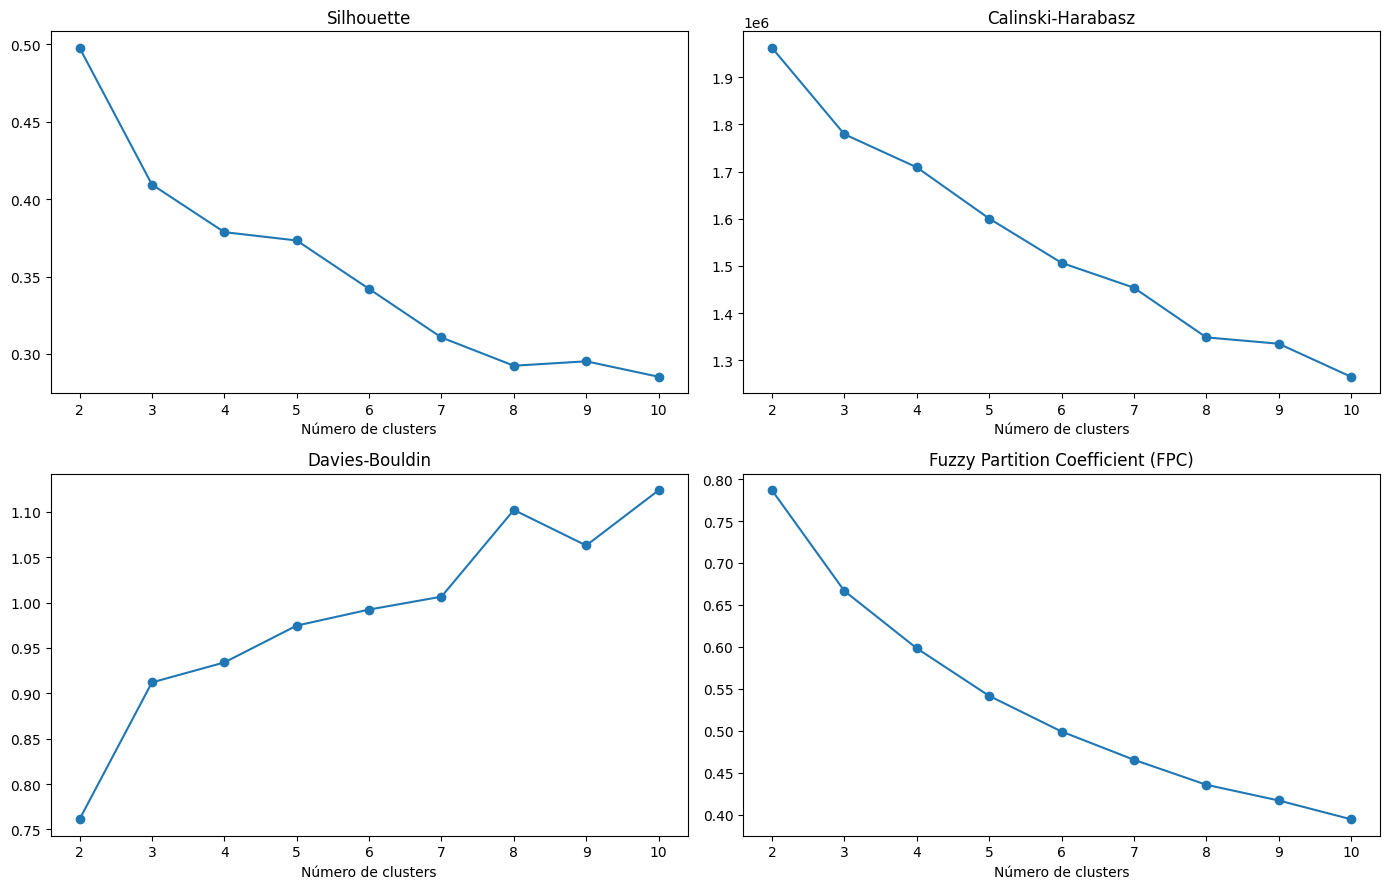

In [5]:
plot_clustering_metrics(
    resultados_fuzzy,
    fourth_metric="fpc",
    fourth_title="Fuzzy Partition Coefficient (FPC)",
)

In [6]:
k_recomendado = int(resultados_fuzzy.loc[resultados_fuzzy["silhouette"].idxmax(), "k"] )
print(f"k recomendado según silhouette: {k_recomendado}")

k recomendado según silhouette: 2


## Ajuste final y perfil de los clusters


In [7]:
modelo, labels = fit_clustering_model(
    model_name="fuzzy",
    k=k_recomendado,
    X=X,
)

cluster_sizes, porcentajes, perfil_clusters, df_clusterizado = analyze_clusters(
    labels=labels,
    df_scaled=df_scaled_modelo,
    df_original=df_original,
    id_col="customer_id",
)

print("Tamaño de los clusters:")
display(cluster_sizes)
print("Porcentaje de clientes:")
display(porcentajes)
print("Perfil medio de los clusters:")
display(perfil_clusters)

Tamaño de los clusters:


cluster
0    565056
1    797225
Name: count, dtype: int64

Porcentaje de clientes:


cluster
0    41.48
1    58.52
Name: proportion, dtype: float64

Perfil medio de los clusters:


,recency,frequency,monetary
cluster,,,
0,77.988,13.484,1.357
1,348.249,1.833,0.148


## Interpretación

Completar tras ejecutar el notebook, comparando recencia, frecuencia, valor y el resto de variables del perfil medio de cada cluster.
